# package_DBR

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors

import package_lab 
import package_DBR

from importlib import reload
package_lab = reload(package_lab)

from package_DBR import myRound, SelectPath_RT, Delay_RT
from package_lab import LL_RT, PID_RT


✅ Classe PID définie et utilisable.


# LL_RT()

In [76]:
help(LL_RT)

Help on function LL_RT in module package_lab:

LL_RT(MV, Kp, Tlag, Tlead, Ts, PV, PVInit=0, method='EBD')
    The function "FO_RT" needs to be included in a "for or while loop".

    :MV: input vector
    :Kp: process gain
    :T: lag time constant [s]
    :Ts: sampling period [s]
    :PV: output vector
    :PVInit: (optional: default value is 0)
    :method: discretisation method (optional: default value is 'EBD')
        EBD: Euler Backward difference
        EFD: Euler Forward difference
        TRAP: Trapezoïdal method

    The function "FO_RT" appends a value to the output vector "PV".
    The appended value is obtained from a recurrent equation that depends on the discretisation method.



(0.0, 100.0)

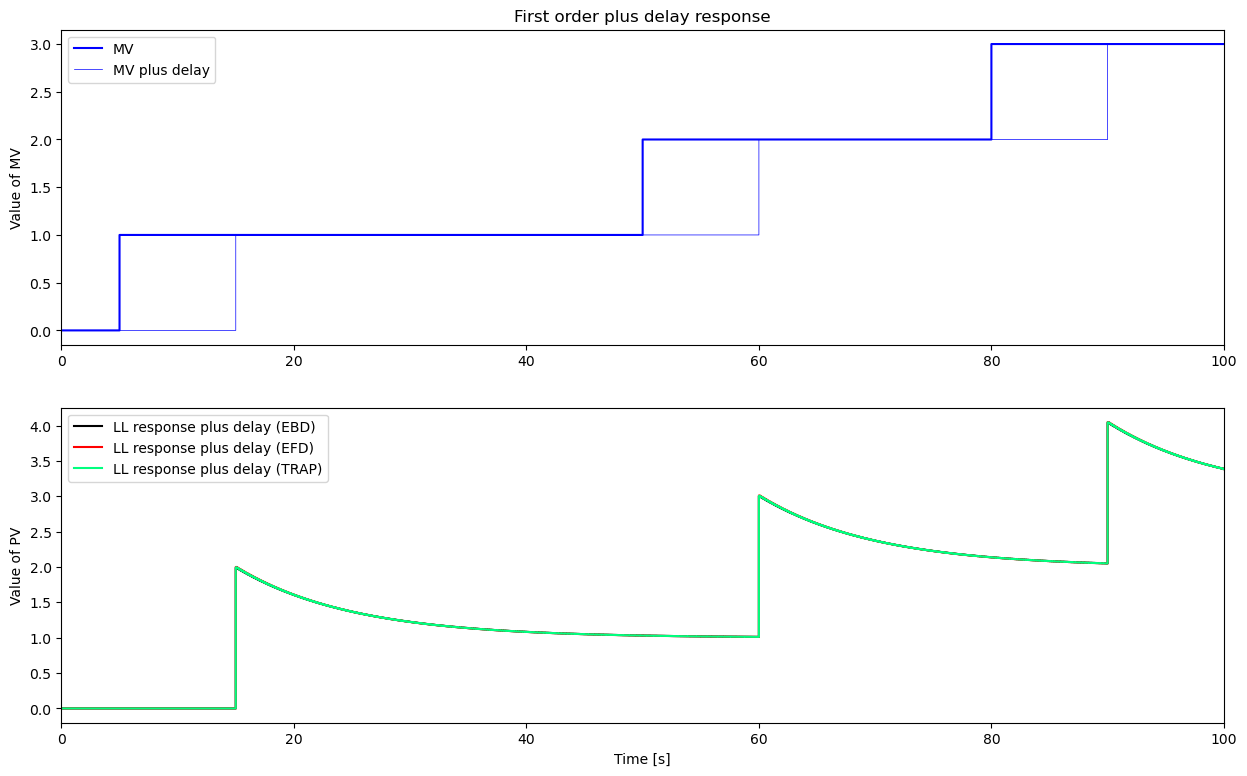

In [77]:
TSim = 100
Ts = 0.1
N = int(TSim/Ts) + 1


# Path for MV
MVPath = {0: 0, 5: 1, 50: 2, 80: 3, TSim: 3}

t = []
MV = []
MVDelay = []
PV_EBD = []
PV_EFD = []
PV_TRAP = []
PV = []


# Parameters
Kp = 1
Tlead = 20
Tlag = 10
theta = 10


for i in range(0,N):
    t.append(i*Ts)
    SelectPath_RT(MVPath,t,MV)
    Delay_RT(MV,theta,Ts,MVDelay)
    LL_RT(MVDelay,Kp,Tlag,Tlead,Ts,PV_EBD)
    LL_RT(MVDelay,Kp,Tlag,Tlead,Ts,PV_EFD,0,'EFD')
    LL_RT(MVDelay,Kp,Tlag,Tlead,Ts,PV_TRAP,0,'TRAP')
    
plt.figure(figsize = (15,9))

plt.subplot(2,1,1)
plt.step(t,MV,'b-',label='MV',where='post')
plt.step(t,MVDelay,'b-',linewidth=0.5,label='MV plus delay',where='post')
plt.ylabel('Value of MV')
plt.title('First order plus delay response')
plt.legend(loc='best')
plt.xlim([0, TSim])

plt.subplot(2,1,2)
plt.step(t,PV_EBD,'black',label='LL response plus delay (EBD)',where='post')
plt.step(t,PV_EFD,'r',label='LL response plus delay (EFD)',where='post')
plt.step(t,PV_TRAP,'springgreen',label='LL response plus delay (TRAP)',where='post')
plt.ylabel('Value of PV')
plt.xlabel('Time [s]')
plt.legend(loc='best')
plt.xlim([0, TSim])    

PID

(0.0, 2000.0)

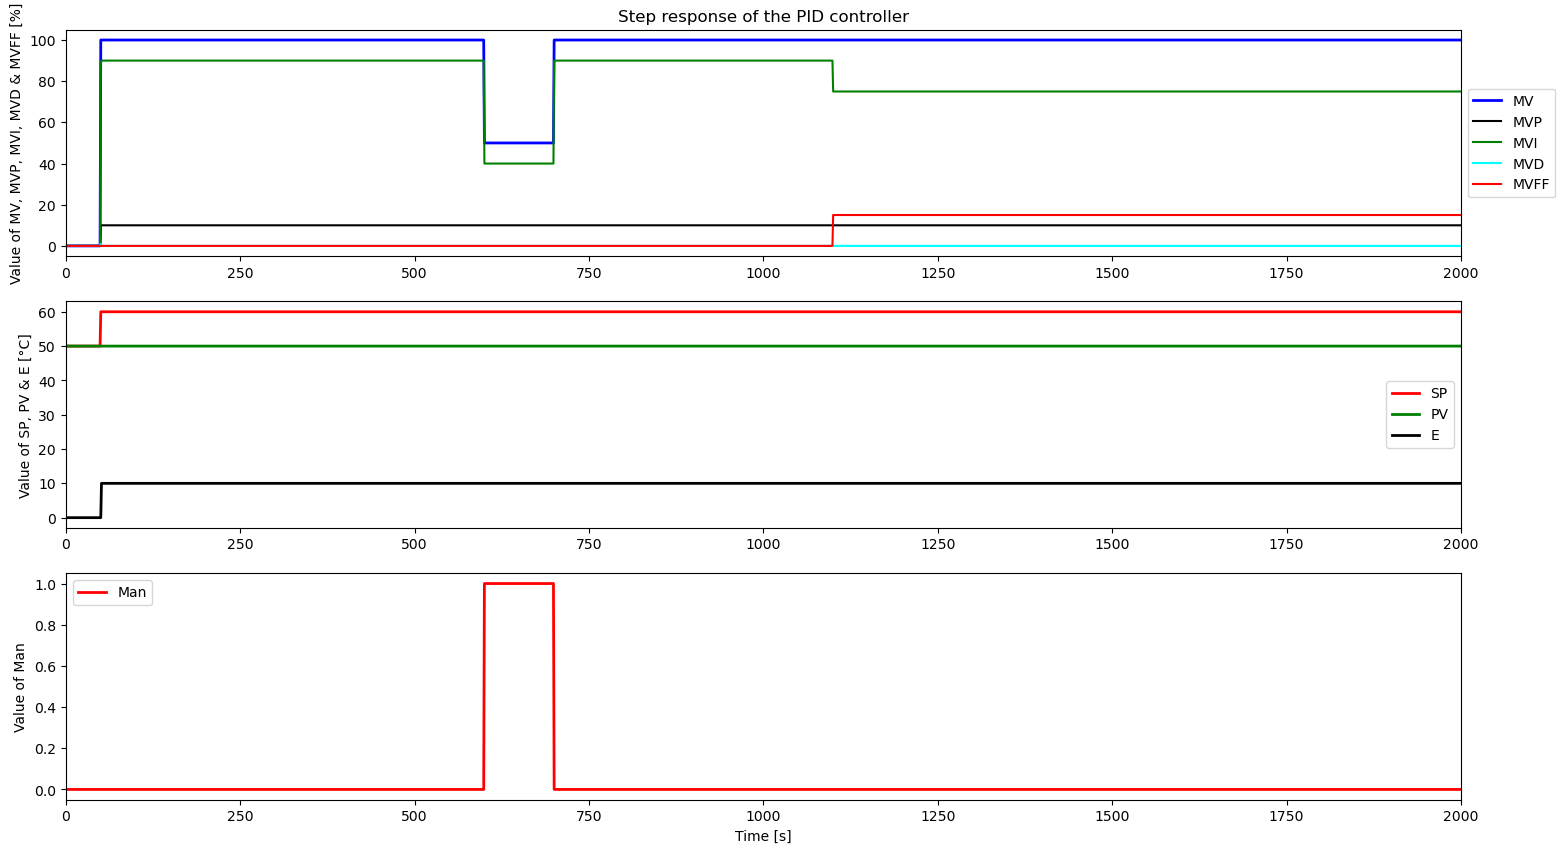

In [ ]:
# ----- Initialisation des vecteurs -----
t, tt = [], []
SP, MV, PV, DV = [], [], [], []
Man, MVMan, MVFF = [], [], []
MVP, MVI, MVD, E = [], [], [], []

# --- Paramètres PID ---
alpha = 0.2

 
Ts = 1
TSim = 2000
MVMin = 0
MVMax = 100
N = int(TSim / Ts) + 1
Kc = 4.3046
Ti = 202.16 
Td = 46.73 


# --- Chemins des signaux ---
ManPath = {0: False, 600: True, 700: False, 1300: False, 1400: False, TSim: False}
MVManPath = {0: 50, TSim: 50}
SPPath = {0: 50, 50: 60, TSim: 60}
PVPath = {0: 50, 50: 50, TSim: 50}
MVFFPath = {0: 0, 1100: 15}

# ----- Boucle de simulation -----
for i in range(0, N):
    t.append(i * Ts)
    tt.append(i * Ts)

    # Mise à jour des signaux en fonction du temps
    SelectPath_RT(SPPath, t, SP)
    SelectPath_RT(PVPath, t, PV)
    SelectPath_RT(ManPath, t, Man)
    SelectPath_RT(MVManPath, t, MVMan)
    SelectPath_RT(MVFFPath, t, MVFF)

    # Vérification avant appel de PID_RT
    if len(E) == 0:
        E.append(0)  # Initialiser E si vide

    # Appel de la fonction PID_RT avec sécurisation
    PID_RT(SP, PV, Man, MVMan, MVFF, Kc, Ti, Td, alpha, Ts, MVMin, MVMax, MV, MVP, MVI, MVD, E, False, 0, "EBD")

# ----- Correction des dimensions avant affichage -----
min_length = min(len(t), len(MV), len(MVP), len(MVI), len(MVD), len(MVFF), len(E), len(Man))
t = t[:min_length]
MV = MV[:min_length]
MVP = MVP[:min_length]
MVI = MVI[:min_length]
MVD = MVD[:min_length]
MVFF = MVFF[:min_length]
E = E[:min_length]
Man = Man[:min_length]

# ----- Affichage des résultats -----
#plt.figure(figsize=(15, 15))


plt.figure(figsize=(18, 10))  # Taille ajustée comme sur l’image

# --- 1. Réponse de la commande PID : MV, MVP, MVI, MVD, MVFF ---
plt.subplot(3, 1, 1)
plt.title('Step response of the PID controller')
plt.plot(t, MV, 'b', linewidth=2, label='MV')       # Commande totale
plt.plot(t, MVP, 'black', linewidth=1.5, label='MVP') # Proportionnel
plt.plot(t, MVI, 'green', linewidth=1.5, label='MVI')# Intégral
plt.plot(t, MVD, 'cyan', linewidth=1.5, label='MVD') # Dérivé
plt.plot(t, MVFF, 'red', linewidth=1.5, label='MVFF')# Feedforward

plt.ylabel('Value of MV, MVP, MVI, MVD & MVFF [%]')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlim([0, TSim])


# --- 2. Réponse du système : SP, PV et erreur E ---
plt.subplot(3, 1, 2)
plt.plot(t, SP, 'red', linewidth=2, label='SP')   # Consigne
plt.plot(t, PV, 'green', linewidth=2, label='PV') # Valeur de sortie
plt.plot(t, E, 'black', linewidth=2, label='E')   # Erreur

plt.ylabel('Value of SP, PV & E [°C]')
plt.legend(loc='best')
plt.xlim([0, TSim])


# --- 3. Mode manuel (Man = 1 ou 0) ---
plt.subplot(3, 1, 3)
plt.plot(t, Man, 'red', linewidth=2, label='Man')
plt.ylabel('Value of Man')
plt.xlabel('Time [s]')
plt.legend(loc='upper left')
plt.xlim([0, TSim])


#plt.savefig("images/PID_output_plot.png", dpi=300, bbox_inches='tight')